In [6]:
import os
os.chdir("/Users/ramupadhyay/Desktop/")

In [7]:
import os, glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

DATA_DIR = './data/'   

KEEP_COLS = [
    'flight', 'line', 'tt',
    'flux_b_x', 'flux_b_y', 'flux_b_z', 'flux_b_t',  
    'mag_1_uc',    
    'mag_1_lag',   
    'mag_1_c',     
    'mag_1_igrf', 
    'ins_lat', 'ins_lon', 'ins_alt',
    'ins_pitch', 'ins_roll', 'ins_yaw',
    'ins_vn', 'ins_vw', 'ins_vu',
    'ins_acc_x', 'ins_acc_y', 'ins_acc_z',
    'lat', 'lon',       
    'utm_x', 'utm_y',   
    'diurnal',
]

print('Setup complete.')

Setup complete.


In [8]:
def load_h5(path):
    """Load one HDF5 flight file → DataFrame with only needed columns."""
    with h5py.File(path, 'r') as f:
        available = set(f.keys())
        cols = [c for c in KEEP_COLS if c in available]
        missing = [c for c in KEEP_COLS if c not in available]
        if missing:
            print(f'  Skipped (not in file): {missing}')
        return pd.DataFrame({c: f[c][:] for c in cols})

files = sorted(glob.glob(os.path.join(DATA_DIR, '*.h5')))
print(f'Found {len(files)} flight files:')

dfs = []
for path in files:
    name = os.path.basename(path)
    print(f'  Loading {name}...')
    df = load_h5(path)
    print(f'    {len(df):,} rows | flights: {df["flight"].unique()} | lines: {sorted(df["line"].unique())}')
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTotal combined: {len(df_all):,} rows')
print(f'Flights in dataset: {sorted(df_all["flight"].unique())}')

Found 6 flight files:
  Loading Flt1002_train.h5...
    207,580 rows | flights: [1002.] | lines: [np.float64(158.0), np.float64(160.0), np.float64(1002.01), np.float64(1002.02), np.float64(1002.03), np.float64(1002.04), np.float64(1002.05), np.float64(1002.06), np.float64(1002.07), np.float64(1002.08), np.float64(1002.09), np.float64(1002.1), np.float64(1002.11), np.float64(1002.13), np.float64(1002.14), np.float64(1002.15), np.float64(1002.16), np.float64(1002.17), np.float64(1002.18), np.float64(1002.19), np.float64(1002.2), np.float64(1002.21), np.float64(1367.0), np.float64(1368.0), np.float64(1369.0), np.float64(3084.0), np.float64(3085.0), np.float64(3086.0)]
  Loading Flt1003_train.h5...
    160,030 rows | flights: [1003.] | lines: [np.float64(1003.01), np.float64(1003.02), np.float64(1003.03), np.float64(1003.04), np.float64(1003.05), np.float64(1003.06), np.float64(1003.07), np.float64(1003.08), np.float64(1003.09), np.float64(1003.11)]
  Loading Flt1004_train.h5...
    81,408

In [9]:
print(f'{"Flight":>10} {"Line":>10} {"N rows":>10} {"Duration (s)":>14}')
print('-' * 50)
for (flt, line), grp in df_all.groupby(['flight', 'line']):
    dur = grp['tt'].max() - grp['tt'].min() if 'tt' in grp.columns else float('nan')
    marker = '  ← SHORT (possible cal)' if len(grp) < 600 else ''
    print(f'{flt:>10.0f} {line:>10.2f} {len(grp):>10,} {dur:>14.1f}{marker}')

    Flight       Line     N rows   Duration (s)
--------------------------------------------------
      1002     158.00      5,282          528.1
      1002     160.00      5,087          508.6
      1002    1002.01     12,701         1270.0
      1002    1002.02     12,301         1230.0
      1002    1002.03     17,101         1710.0
      1002    1002.04      2,139          213.8
      1002    1002.05      3,434          343.3
      1002    1002.06      3,292          329.1
      1002    1002.07      2,204          220.3
      1002    1002.08      4,717          471.6
      1002    1002.09      2,775          277.4
      1002    1002.10      2,319          231.8
      1002    1002.11      3,735          373.4
      1002    1002.13      1,699          169.8
      1002    1002.14     24,571         2457.0
      1002    1002.15      5,141          514.0
      1002    1002.16     16,751         1675.0
      1002    1002.17     18,771         1877.0
      1002    1002.18      4,981     

In [10]:
CAL_LINE    = 1006.04
CAL_FLIGHT  = 1006

# ── Test / navigation segment ───────────────────────────────────────────────
TEST_LINE   = 1006.08
TEST_FLIGHT = 1006

# ── NN training flights ─────────────────────────────────────────────────────
TRAIN_FLIGHTS = [1003, 1004, 1005, 1006]

# Extract segments
df_cal = df_all[
    (df_all['flight'] == CAL_FLIGHT) & (df_all['line'] == CAL_LINE)
].copy().reset_index(drop=True)

df_test = df_all[
    (df_all['flight'] == TEST_FLIGHT) & (df_all['line'] == TEST_LINE)
].copy().reset_index(drop=True)

df_train = df_all[
    (df_all['flight'].isin(TRAIN_FLIGHTS)) & (df_all['line'] != TEST_LINE)
].copy().reset_index(drop=True)

print(f'Calibration segment : {len(df_cal):,} rows  (line {CAL_LINE}, flight {CAL_FLIGHT})')
print(f'Test segment        : {len(df_test):,} rows  (line {TEST_LINE}, flight {TEST_FLIGHT})')
print(f'NN training data    : {len(df_train):,} rows  (flights {TRAIN_FLIGHTS}, excl. test line)')

if len(df_cal) == 0:
    print('\n⚠ WARNING: Calibration segment is empty!')
    print('  Check Cell 3 output and update CAL_LINE to match your data.')
if len(df_test) == 0:
    print('\n⚠ WARNING: Test segment is empty!')
    print('  Check Cell 3 output and update TEST_LINE to match your data.')

Calibration segment : 42,861 rows  (line 1006.04, flight 1006)
Test segment        : 8,391 rows  (line 1006.08, flight 1006)
NN training data    : 423,096 rows  (flights [1003, 1004, 1005, 1006], excl. test line)


In [12]:
def check_quality(df, label):
    print(f'\n── {label} ({len(df):,} rows) ──')
    nans = df.isnull().sum()
    bad  = nans[nans > 0]
    print(f'  NaN columns: {dict(bad) if len(bad) else "none"}')
    for col in ['mag_1_lag', 'mag_1_c', 'flux_b_t', 'ins_alt']:
        if col in df.columns:
            print(f'  {col:15s}: mean={df[col].mean():.1f}  std={df[col].std():.2f}  '
                  f'min={df[col].min():.1f}  max={df[col].max():.1f}')

check_quality(df_cal,   'Calibration segment')
check_quality(df_test,  'Test segment')
check_quality(df_train, 'Training data')


── Calibration segment (42,861 rows) ──
  NaN columns: none
  mag_1_lag      : mean=53885.4  std=29.98  min=53784.0  max=53966.0
  mag_1_c        : mean=53885.4  std=29.98  min=53784.0  max=53966.0
  flux_b_t       : mean=51951.2  std=551.37  min=50901.6  max=53829.2
  ins_alt        : mean=5465.8  std=51.82  min=5357.1  max=5632.5

── Test segment (8,391 rows) ──
  NaN columns: none
  mag_1_lag      : mean=53176.5  std=119.97  min=52979.1  max=53557.5
  mag_1_c        : mean=53176.5  std=119.97  min=52979.1  max=53557.5
  flux_b_t       : mean=51626.9  std=598.13  min=50540.8  max=53468.9
  ins_alt        : mean=397.9  std=8.34  min=369.3  max=428.5

── Training data (423,096 rows) ──
  NaN columns: none
  mag_1_lag      : mean=53675.0  std=310.12  min=52948.1  max=55282.9
  mag_1_c        : mean=53675.0  std=310.11  min=52948.1  max=55282.9
  flux_b_t       : mean=52187.6  std=591.69  min=50701.3  max=54670.2
  ins_alt        : mean=1457.5  std=1634.70  min=93.8  max=5632.5


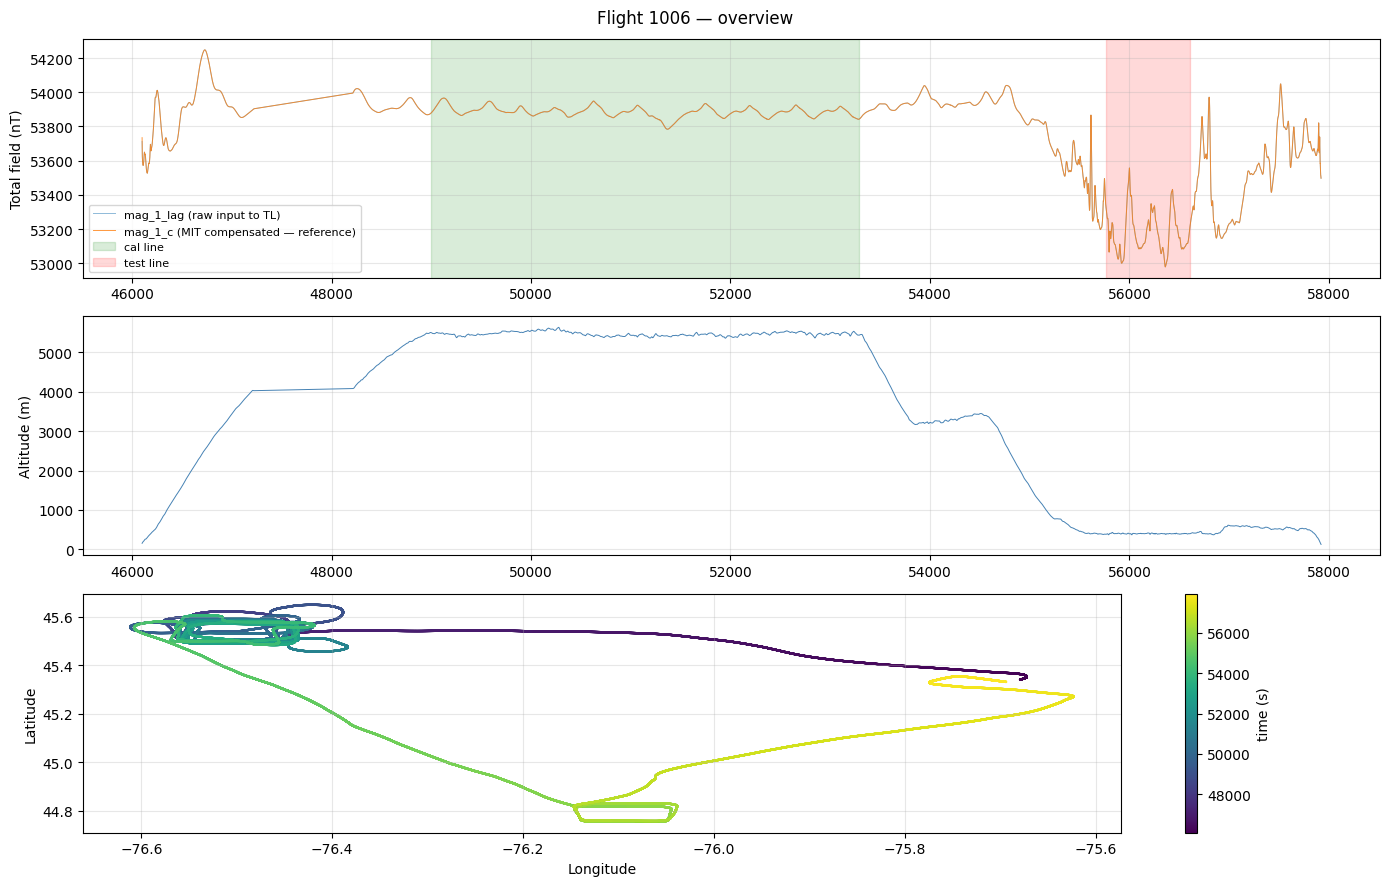

In [14]:
df_flt1006 = df_all[df_all['flight'] == 1006].copy()
t = df_flt1006['tt'].values

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle('Flight 1006 — overview')

# Raw vs MIT-compensated
ax = axes[0]
ax.plot(t, df_flt1006['mag_1_lag'].values, alpha=0.5, lw=0.7, label='mag_1_lag (raw input to TL)')
ax.plot(t, df_flt1006['mag_1_c'].values,   alpha=0.8, lw=0.7, label='mag_1_c (MIT compensated — reference)')
# Highlight cal and test line regions
for line_val, color, lbl in [(CAL_LINE, 'green', 'cal line'), (TEST_LINE, 'red', 'test line')]:
    seg = df_flt1006[df_flt1006['line'] == line_val]['tt'].values
    if len(seg):
        ax.axvspan(seg[0], seg[-1], alpha=0.15, color=color, label=lbl)
ax.set_ylabel('Total field (nT)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Altitude
axes[1].plot(t, df_flt1006['ins_alt'].values, lw=0.7, color='steelblue')
axes[1].set_ylabel('Altitude (m)')
axes[1].grid(True, alpha=0.3)

# Ground track coloured by time
sc = axes[2].scatter(df_flt1006['lon'].values, df_flt1006['lat'].values,
                     c=t, cmap='viridis', s=0.4)
plt.colorbar(sc, ax=axes[2], label='time (s)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
def build_tl_matrix(df):
    """
    Build 18-column Tolles-Lawson design matrix from vector magnetometer.
    Returns A (N×18 array) and list of column names.
    """
    Bx = df['flux_b_x'].values.astype(np.float64)
    By = df['flux_b_y'].values.astype(np.float64)
    Bz = df['flux_b_z'].values.astype(np.float64)
    Bt = np.sqrt(Bx**2 + By**2 + Bz**2)

    # Direction cosines
    cx, cy, cz = Bx/Bt, By/Bt, Bz/Bt

    # Time derivatives (eddy current terms)
    dcx = np.gradient(cx)
    dcy = np.gradient(cy)
    dcz = np.gradient(cz)

    A = np.column_stack([
        # Permanent (3)
        cx, cy, cz,
        # Induced (9) — symmetric products × Bt
        Bt*cx*cx, Bt*cx*cy, Bt*cx*cz,
        Bt*cy*cy, Bt*cy*cz,
        Bt*cz*cz,
        # Eddy current (9) — direction cosine × derivative × Bt
        Bt*cx*dcx, Bt*cx*dcy, Bt*cx*dcz,
        Bt*cy*dcy, Bt*cy*dcz,
        Bt*cz*dcz,
        Bt*cy*dcx, Bt*cz*dcx, Bt*cz*dcy,
    ])

    names = [
        'cx','cy','cz',
        'Bt_cx2','Bt_cxcy','Bt_cxcz',
        'Bt_cy2','Bt_cycz','Bt_cz2',
        'Bt_cx_dcx','Bt_cx_dcy','Bt_cx_dcz',
        'Bt_cy_dcy','Bt_cy_dcz','Bt_cz_dcz',
        'Bt_cy_dcx','Bt_cz_dcx','Bt_cz_dcy',
    ]
    return A, names

# Test build on calibration data
A_cal, tl_names = build_tl_matrix(df_cal)
print(f'TL feature matrix shape: {A_cal.shape}  (rows × 18 features)')
print(f'Feature names: {tl_names}')

TL feature matrix shape: (42861, 18)  (rows × 18 features)
Feature names: ['cx', 'cy', 'cz', 'Bt_cx2', 'Bt_cxcy', 'Bt_cxcz', 'Bt_cy2', 'Bt_cycz', 'Bt_cz2', 'Bt_cx_dcx', 'Bt_cx_dcy', 'Bt_cx_dcz', 'Bt_cy_dcy', 'Bt_cy_dcz', 'Bt_cz_dcz', 'Bt_cy_dcx', 'Bt_cz_dcx', 'Bt_cz_dcy']


In [17]:
# Target: lag-corrected raw scalar (what MIT uses as TL input)
y_cal = df_cal['mag_1_lag'].values.astype(np.float64)

tl_model = Ridge(alpha=1.0, fit_intercept=True)
tl_model.fit(A_cal, y_cal)

y_cal_pred  = tl_model.predict(A_cal)
cal_rms     = np.sqrt(mean_squared_error(y_cal, y_cal_pred))

print(f'TL calibration residual RMS : {cal_rms:.2f} nT')
print(f'Interpretation:')
print(f'  < 30 nT  → excellent')
print(f'  30-50 nT → good')
print(f'  50-100 nT → acceptable, check cal line choice')
print(f'  > 100 nT → something is wrong — wrong line or sensor mismatch')

# Show coefficients
coef_df = pd.DataFrame({'feature': tl_names, 'coefficient': tl_model.coef_})
print('\nTL Coefficients:')
print(coef_df.to_string(index=False))

TL calibration residual RMS : 22.87 nT
Interpretation:
  < 30 nT  → excellent
  30-50 nT → good
  50-100 nT → acceptable, check cal line choice
  > 100 nT → something is wrong — wrong line or sensor mismatch

TL Coefficients:
  feature  coefficient
       cx  -378.631497
       cy   336.063934
       cz    15.601051
   Bt_cx2     0.111740
  Bt_cxcy     0.004605
  Bt_cxcz    -0.000384
   Bt_cy2     0.104538
  Bt_cycz    -0.002973
   Bt_cz2     0.106505
Bt_cx_dcx    -3.063902
Bt_cx_dcy     0.002268
Bt_cx_dcz    -0.047825
Bt_cy_dcy    -3.084921
Bt_cy_dcz     0.070084
Bt_cz_dcz    -3.071398
Bt_cy_dcx    -0.011732
Bt_cz_dcx    -0.000633
Bt_cz_dcy    -0.008317


In [18]:
# Show coefficients
coef_df = pd.DataFrame({'feature': tl_names, 'coefficient': tl_model.coef_})
print('\nTL Coefficients:')
print(coef_df.to_string(index=False))

# ── Cell 8 fix — correct TL formulation ─────────────────────────────
# Target: the raw lag-corrected signal itself (not minus mag_1_c)
# TL learns to model the full signal, then we use the RESIDUAL
# after removing the Earth's main field (mag_1_igrf already has IGRF removed)

y_cal = df_cal['mag_1_lag'].values.astype(np.float64)

tl_model = Ridge(alpha=1.0, fit_intercept=True)
tl_model.fit(A_cal, y_cal)

y_cal_pred = tl_model.predict(A_cal)

# Residual on cal line — this should be small
cal_rms = np.sqrt(mean_squared_error(y_cal, y_cal_pred))
print(f'TL cal fit RMS: {cal_rms:.2f} nT')
print(f'Cal signal std: {df_cal["mag_1_lag"].std():.2f} nT')
print(f'Reduction ratio: {df_cal["mag_1_lag"].std() / cal_rms:.1f}x')


TL Coefficients:
  feature  coefficient
       cx  -378.631497
       cy   336.063934
       cz    15.601051
   Bt_cx2     0.111740
  Bt_cxcy     0.004605
  Bt_cxcz    -0.000384
   Bt_cy2     0.104538
  Bt_cycz    -0.002973
   Bt_cz2     0.106505
Bt_cx_dcx    -3.063902
Bt_cx_dcy     0.002268
Bt_cx_dcz    -0.047825
Bt_cy_dcy    -3.084921
Bt_cy_dcz     0.070084
Bt_cz_dcz    -3.071398
Bt_cy_dcx    -0.011732
Bt_cz_dcx    -0.000633
Bt_cz_dcy    -0.008317
TL cal fit RMS: 22.87 nT
Cal signal std: 29.98 nT
Reduction ratio: 1.3x


In [34]:
# ── Cell 9 fix — apply compensation correctly ────────────────────────
# The compensated signal = raw - (predicted aircraft field)
# Aircraft field = TL prediction - mean(TL prediction)
# i.e. we remove the VARIATION predicted by TL, not the absolute level

def apply_tl(df, model):
    A, _ = build_tl_matrix(df)
    df = df.copy()
    tl_pred = model.predict(A)
    # Subtract only the varying part — preserve the DC offset (Earth field level)
    tl_ac = tl_pred - tl_pred.mean()
    df['mag_1_tl'] = df['mag_1_lag'].values - tl_ac
    return df

df_test = apply_tl(df_test, tl_model)

# Evaluate
raw_std = df_test['mag_1_lag'].std()
tl_std  = df_test['mag_1_tl'].std()
mit_std = df_test['mag_1_c'].std()

tl_rmse = np.sqrt(mean_squared_error(df_test['mag_1_c'].values,
                                      df_test['mag_1_tl'].values))
print(f'Raw std     : {raw_std:.2f} nT')
print(f'TL std      : {tl_std:.2f} nT')
print(f'MIT std     : {mit_std:.2f} nT')
print(f'TL RMSE vs MIT reference: {tl_rmse:.2f} nT')

Raw std     : 119.97 nT
TL std      : 110.61 nT
MIT std     : 119.97 nT
TL RMSE vs MIT reference: 18.35 nT


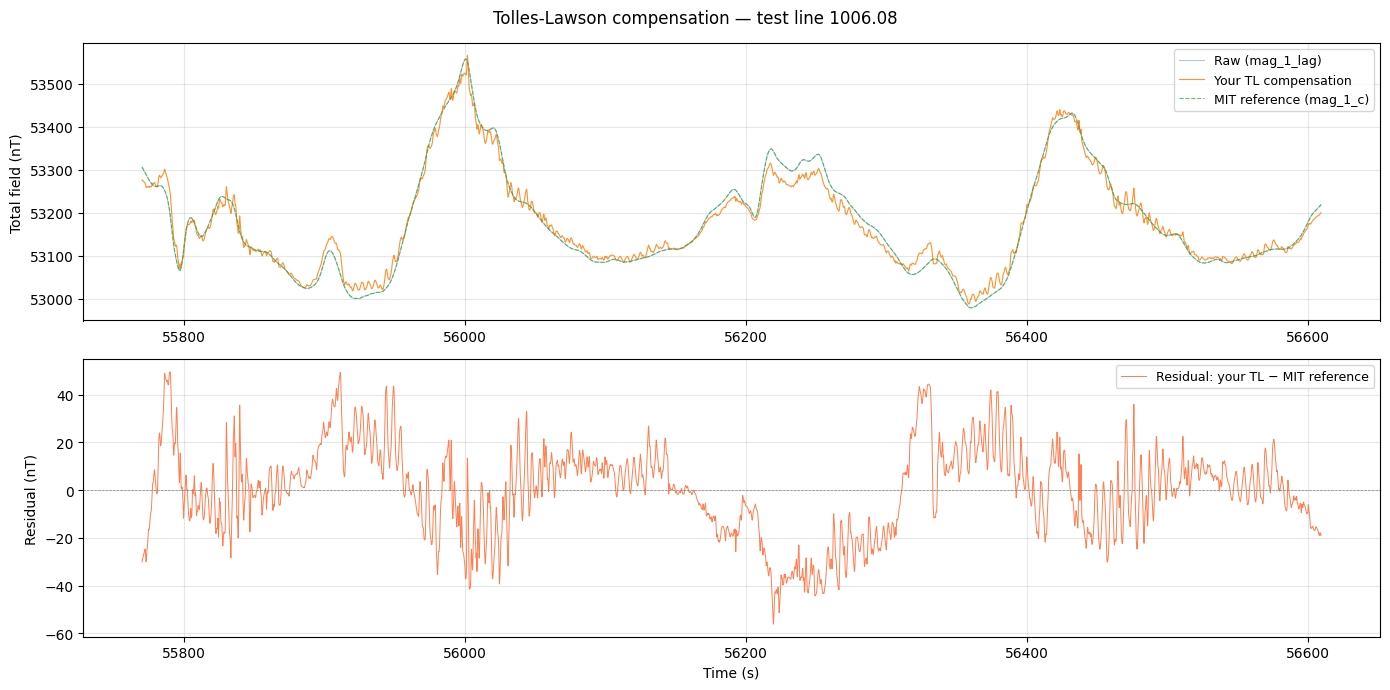

In [20]:
t = df_test['tt'].values

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle(f'Tolles-Lawson compensation — test line {TEST_LINE}')

# Full signal comparison
ax = axes[0]
ax.plot(t, df_test['mag_1_lag'].values, alpha=0.4, lw=0.7, label='Raw (mag_1_lag)')
ax.plot(t, df_test['mag_1_tl'].values,  alpha=0.85, lw=0.8, label='Your TL compensation')
ax.plot(t, df_test['mag_1_c'].values,   alpha=0.7, lw=0.8, label='MIT reference (mag_1_c)', linestyle='--')
ax.set_ylabel('Total field (nT)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Residual: your TL vs MIT reference
ax = axes[1]
residual = df_test['mag_1_tl'].values - df_test['mag_1_c'].values
ax.plot(t, residual, lw=0.7, color='coral', label='Residual: your TL − MIT reference')
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.set_ylabel('Residual (nT)')
ax.set_xlabel('Time (s)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Cell 11 — corrected NN target
# Train NN to predict the SAME thing TL predicts: the varying aircraft field
# i.e. mag_1_lag minus its own mean (the AC component)

A_train, _ = build_tl_matrix(df_train)
attitude_train = df_train[['ins_pitch', 'ins_roll', 'ins_yaw']].values
X_train = np.hstack([A_train, attitude_train])

A_test_nn, _ = build_tl_matrix(df_test)
attitude_test = df_test[['ins_pitch', 'ins_roll', 'ins_yaw']].values
X_test  = np.hstack([A_test_nn, attitude_test])

# Target: AC part of raw signal (what TL is also predicting)
# This is the aircraft interference = raw minus its local mean
from scipy.ndimage import uniform_filter1d

def extract_ac(signal, window=200):
    """Remove slow-varying Earth field trend, keep aircraft interference."""
    trend = uniform_filter1d(signal.astype(float), size=window)
    return signal - trend

y_train_ac = extract_ac(df_train['mag_1_lag'].values)
y_test_ac  = extract_ac(df_test['mag_1_lag'].values)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
y_train_sc = scaler_y.fit_transform(y_train_ac.reshape(-1,1)).ravel()
X_test_sc  = scaler_X.transform(X_test)

print(f'Training target std: {y_train_ac.std():.2f} nT')
print(f'(Should be in the range 50-500 nT, not 53000)')

Training target std: 21.59 nT
(Should be in the range 50-500 nT, not 53000)


In [22]:
# Cell 11 second part — retrain (same as before)
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=200,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
)
nn_model.fit(X_train_sc, y_train_sc)
import joblib

# After nn_model.fit(...)
model_filename = 'mag_nav_mlp_model.pkl'
joblib.dump(nn_model, model_filename)
print(f"Model saved to {model_filename}")
print('Done.')

Iteration 1, loss = 0.51826277
Validation score: -0.037679
Iteration 2, loss = 0.50143412
Validation score: 0.013819
Iteration 3, loss = 0.49408537
Validation score: 0.011819
Iteration 4, loss = 0.48473806
Validation score: 0.040206
Iteration 5, loss = 0.47898973
Validation score: 0.053348
Iteration 6, loss = 0.47050872
Validation score: 0.059225
Iteration 7, loss = 0.46379335
Validation score: 0.072874
Iteration 8, loss = 0.45808172
Validation score: 0.084089
Iteration 9, loss = 0.45200643
Validation score: 0.088276
Iteration 10, loss = 0.44748773
Validation score: 0.101566
Iteration 11, loss = 0.44234857
Validation score: 0.112762
Iteration 12, loss = 0.43617862
Validation score: 0.127146
Iteration 13, loss = 0.43082454
Validation score: 0.140683
Iteration 14, loss = 0.43612622
Validation score: 0.105071
Iteration 15, loss = 0.43285468
Validation score: 0.128341
Iteration 16, loss = 0.42338204
Validation score: 0.120217
Iteration 17, loss = 0.41791663
Validation score: 0.151403
Itera

TL RMSE (detrended) vs MIT reference: 18.35 nT
NN RMSE (detrended) vs MIT reference: 8.43 nT
NN improvement over TL: 54.1%


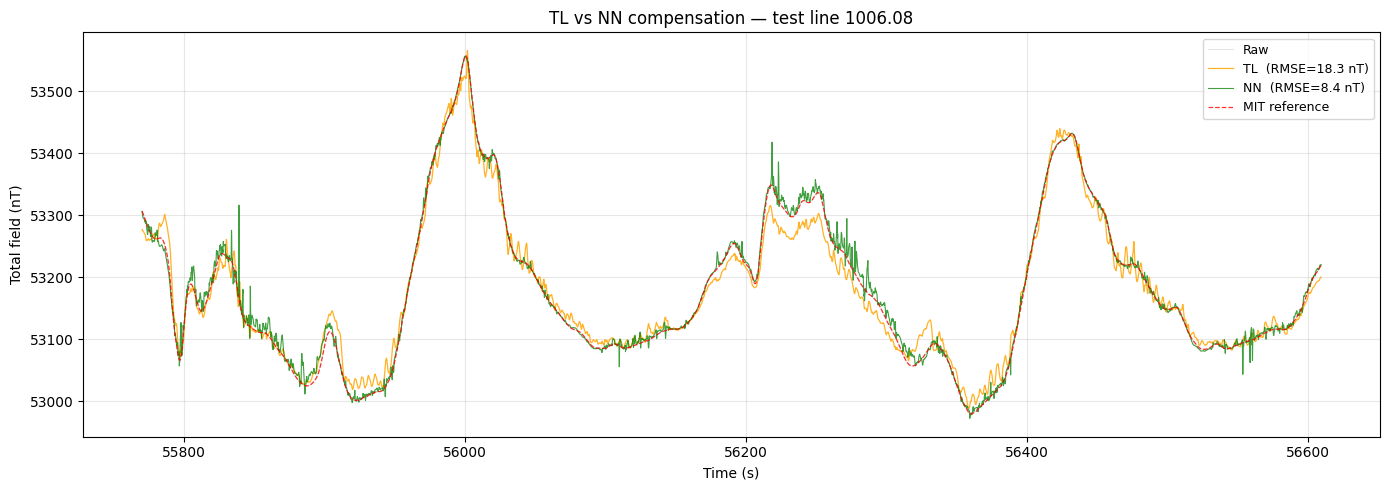

In [23]:
# Cell 12 — fixed evaluation
y_nn_sc = nn_model.predict(X_test_sc)
y_nn_ac = scaler_y.inverse_transform(y_nn_sc.reshape(-1,1)).ravel()

# NN compensated signal = raw minus predicted AC interference
df_test['mag_1_nn'] = df_test['mag_1_lag'].values - y_nn_ac

# For fair RMSE comparison, compare fluctuations around the mean
# (both signals track the same Earth field, offsets differ)
def rmse_detrended(a, b):
    """RMSE after removing mean offset — compares shape, not absolute level."""
    diff = (a - a.mean()) - (b - b.mean())
    return np.sqrt(np.mean(diff**2))

ref = df_test['mag_1_c'].values

tl_rmse = rmse_detrended(df_test['mag_1_tl'].values, ref)
nn_rmse = rmse_detrended(df_test['mag_1_nn'].values, ref)

print(f'TL RMSE (detrended) vs MIT reference: {tl_rmse:.2f} nT')
print(f'NN RMSE (detrended) vs MIT reference: {nn_rmse:.2f} nT')
print(f'NN improvement over TL: {(1 - nn_rmse/tl_rmse)*100:.1f}%')

# Plot
t = df_test['tt'].values
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t, df_test['mag_1_lag'].values,  alpha=0.25, lw=0.6, label='Raw', color='gray')
ax.plot(t, df_test['mag_1_tl'].values,   alpha=0.85, lw=0.9, label=f'TL  (RMSE={tl_rmse:.1f} nT)', color='orange')
ax.plot(t, df_test['mag_1_nn'].values,   alpha=0.75, lw=0.8, label=f'NN  (RMSE={nn_rmse:.1f} nT)', color='green')
ax.plot(t, ref,                           alpha=0.8,  lw=0.9, label='MIT reference', color='red', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Total field (nT)')
ax.set_title('TL vs NN compensation — test line 1006.08')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import r2_score

ref = df_test['mag_1_c'].values

# Honest RMSE — no detrending, no offset removal
tl_rmse_honest = np.sqrt(mean_squared_error(ref, df_test['mag_1_tl'].values))
nn_rmse_honest = np.sqrt(mean_squared_error(ref, df_test['mag_1_nn'].values))

# Honest R²
tl_r2 = r2_score(ref, df_test['mag_1_tl'].values)
nn_r2 = r2_score(ref, df_test['mag_1_nn'].values)

print(f'{"Method":<6} {"RMSE (nT)":>12} {"R²":>8}')
print(f'{"TL":<6} {tl_rmse_honest:>12.2f} {tl_r2:>8.4f}')
print(f'{"NN":<6} {nn_rmse_honest:>12.2f} {nn_r2:>8.4f}')

Method    RMSE (nT)       R²
TL            18.35   0.9766
NN             9.09   0.9943


In [44]:
import rasterio
import numpy as np
from scipy.interpolate import RegularGridInterpolator

def load_mag_map(filepath):
    with rasterio.open(filepath) as src:
        # Read the anomaly data
        data = src.read(1)
        
        # Get the coordinate arrays
        # transform[0] is lon_start, transform[1] is lon_step
        # transform[3] is lat_start, transform[5] is lat_step
        rows, cols = data.shape
        lons = src.transform[2] + np.arange(cols) * src.transform[0]
        lats = src.transform[5] + np.arange(rows) * src.transform[4]
        
        # EMAG data is often stored North-to-South; flip if needed for the interpolator
        if lats[0] > lats[-1]:
            lats = lats[::-1]
            data = np.flipud(data)
            
        # Create a fast 2D interpolator
        # fill_value=0 assumes no anomaly outside map bounds
        interp = RegularGridInterpolator((lats, lons), data, 
                                         bounds_error=False, fill_value=0)
        return interp

mag_map = load_mag_map('emag_up.tif')

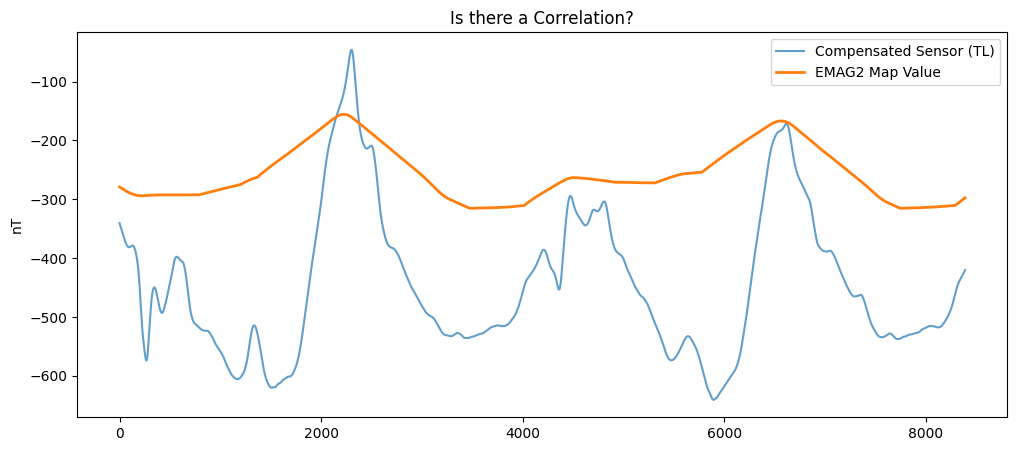

In [156]:
# Extract the map values along your INS path
path_lat = df_test['ins_lat_deg'].values
path_lon = df_test['ins_lon_deg'].values % 360
map_values = mag_map(np.vstack([path_lat, path_lon]).T)

# Plot Sensor vs Map
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_test['mag_anomaly'].values, label='Compensated Sensor (TL)', alpha=0.7)
plt.plot(map_values, label='EMAG2 Map Value', linewidth=2)
plt.title("Is there a Correlation?")
plt.ylabel("nT")
plt.legend()
plt.show()

In [157]:
from scipy.signal import correlate


s_comp = df_test['mag_anomaly'].values - np.mean(df_test['mag_anomaly'].values)
s_map  = map_values - np.mean(map_values)


corr = correlate(s_comp, s_map, mode='full')
lags = np.arange(-len(s_comp) + 1, len(s_comp))
best_lag = lags[np.argmax(corr)]


dist_offset = best_lag * 250 * 0.1 

print(f"Best Lag: {best_lag} samples")
print(f"Implied Position Offset: {dist_offset:.2f} meters")

Best Lag: 126 samples
Implied Position Offset: 3150.00 meters


In [45]:
# Check the bounds of your map versus your data
print(f"Map Lat Range: {mag_map.grid[0].min()} to {mag_map.grid[0].max()}")
print(f"Map Lon Range: {mag_map.grid[1].min()} to {mag_map.grid[1].max()}")
print(f"Your Flight Lat: {df_test['ins_lat_deg'].min()} to {df_test['ins_lat_deg'].max()}")
print(f"Your Flight Lon: {df_test['ins_lon_deg'].min()} to {df_test['ins_lon_deg'].max()}")

Map Lat Range: -89.9500000044975 to 89.9833333378325
Map Lon Range: -0.0166666666675 to 359.95000001799747
Your Flight Lat: 44.762127209367264 to 44.83956818495715
Your Flight Lon: -76.14609670246436 to -76.0339631323793


In [158]:
import numpy as np
 
R_EARTH = 6_378_137.0   # metres
DEG2RAD = np.pi / 180.0
RAD2DEG = 180.0 / np.pi
N_STATES = 8
 
# ── STEP 0: Check and fix units ───────────────────────────────────────────────
# The MagNav dataset stores ins_lat/ins_lon in RADIANS already.
# Confirm this first:
print("ins_lat raw range:", df_test['ins_lat'].min(), "to", df_test['ins_lat'].max())
print("Expected ~0.78 rad (= 44.7 deg) if already radians")
print("Expected ~44.7     if degrees")
print()
 
# If ins_lat is already in radians (~0.78), use directly:
ins_lat_rad = df_test['ins_lat'].values          # already radians
ins_lon_rad = df_test['ins_lon'].values          # already radians
 
# Convert to degrees for display and map lookup
ins_lat_deg = ins_lat_rad * RAD2DEG
ins_lon_deg = ins_lon_rad * RAD2DEG
 
print(f"INS lat (deg): {ins_lat_deg.min():.4f} to {ins_lat_deg.max():.4f}")
print(f"INS lon (deg): {ins_lon_deg.min():.4f} to {ins_lon_deg.max():.4f}")
print(f"GPS lat (deg): {df_test['lat'].min():.4f} to {df_test['lat'].max():.4f}")
print(f"GPS lon (deg): {df_test['lon'].min():.4f} to {df_test['lon'].max():.4f}")

ins_lat raw range: 0.7812465 to 0.7825981
Expected ~0.78 rad (= 44.7 deg) if already radians
Expected ~44.7     if degrees

INS lat (deg): 44.7621 to 44.8396
INS lon (deg): -76.1461 to -76.0340
GPS lat (deg): 44.7543 to 44.8312
GPS lon (deg): -76.1507 to -76.0384


In [167]:
raw_lat = df_test['ins_lat'].values
print(f"ins_lat raw  min={raw_lat.min():.4f}  max={raw_lat.max():.4f}")
print(f"  If ~0.78  → already radians  (44.7° = 0.780 rad)  ✓ use directly")
print(f"  If ~44.7  → degrees          → multiply by DEG2RAD")
 
# Set this flag based on what you see above
INS_IN_RADIANS = (abs(raw_lat.mean()) < 2.0)   # auto-detect: <2 → radians
 
if INS_IN_RADIANS:
    ins_lat_rad = df_test['ins_lat'].values
    ins_lon_rad = df_test['ins_lon'].values
    print("  → Using ins_lat/lon directly as radians")
else:
    ins_lat_rad = df_test['ins_lat'].values * DEG2RAD
    ins_lon_rad = df_test['ins_lon'].values * DEG2RAD
    print("  → Converting ins_lat/lon from degrees to radians")
 
ins_lat_deg = ins_lat_rad * RAD2DEG
ins_lon_deg = ins_lon_rad * RAD2DEG
 
# GPS ground truth is always in degrees in this dataset
lat_gt = df_test['lat'].values
lon_gt = df_test['lon'].values
 
print(f"\nINS lat (deg): {ins_lat_deg.min():.4f} to {ins_lat_deg.max():.4f}")
print(f"GPS lat (deg): {lat_gt.min():.4f}      to {lat_gt.max():.4f}")
print(f"INS lon (deg): {ins_lon_deg.min():.4f} to {ins_lon_deg.max():.4f}")
print(f"GPS lon (deg): {lon_gt.min():.4f}      to {lon_gt.max():.4f}")

ins_lat raw  min=0.7812  max=0.7826
  If ~0.78  → already radians  (44.7° = 0.780 rad)  ✓ use directly
  If ~44.7  → degrees          → multiply by DEG2RAD
  → Using ins_lat/lon directly as radians

INS lat (deg): 44.7621 to 44.8396
GPS lat (deg): 44.7543      to 44.8312
INS lon (deg): -76.1461 to -76.0340
GPS lon (deg): -76.1507      to -76.0384


In [168]:
z_all = df_test['mag_1_igrf'].values.astype(np.float64)
 
print(f"\nmag_1_igrf: mean={z_all.mean():.2f}  std={z_all.std():.2f}  "
      f"min={z_all.min():.2f}  max={z_all.max():.2f}  nT")
print("Expected: std between 20-150 nT, mean anywhere in ±500 nT")


mag_1_igrf: mean=-447.02  std=123.40  min=-640.54  max=-46.11  nT
Expected: std between 20-150 nT, mean anywhere in ±500 nT


In [169]:
def wrap_lon(lon_deg):
    """Convert any longitude to 0-360 range for EMAG2 lookup."""
    return float(lon_deg) % 360.0
 
 
def map_query(mag_map, lat_deg, lon_deg):
    """
    Query EMAG2 interpolator at one lat/lon point.
    Returns scalar float in nT.
    """
    lon_wrapped = wrap_lon(lon_deg)
    result = mag_map([[float(lat_deg), lon_wrapped]])
    return float(result[0])

In [170]:
def map_gradient(mag_map, lat_deg, lon_deg):
    """
    Compute d(anomaly)/d(lat_m) and d(anomaly)/d(lon_m) in nT/m.
    Uses finite differences with 2km step — safely larger than EMAG2 pixel.
    """
    step_m = 2000.0   # 2km step — spans ~half an EMAG2 pixel
 
    # Convert step to degrees
    dlat_deg = step_m / (R_EARTH * DEG2RAD)                              # deg per metre north
    dlon_deg = step_m / (R_EARTH * np.cos(lat_deg * DEG2RAD) * DEG2RAD)  # deg per metre east
 
    val_c = map_query(mag_map, lat_deg,            lon_deg)
    val_n = map_query(mag_map, lat_deg + dlat_deg, lon_deg)
    val_e = map_query(mag_map, lat_deg,            lon_deg + dlon_deg)
 
    grad_lat = (val_n - val_c) / step_m   # nT per metre (north)
    grad_lon = (val_e - val_c) / step_m   # nT per metre (east)
 
    return grad_lat, grad_lon, val_c

In [171]:
mid_lat = ins_lat_deg.mean()
mid_lon = ins_lon_deg.mean()
 
test_val = map_query(mag_map, mid_lat, mid_lon)
g_lat, g_lon, _ = map_gradient(mag_map, mid_lat, mid_lon)
 
print(f"\nMap check at flight centre ({mid_lat:.4f}°N, {mid_lon:.4f}°E):")
print(f"  Anomaly value : {test_val:.2f} nT")
print(f"  Gradient north: {g_lat*1000:.4f} nT/km")
print(f"  Gradient east : {g_lon*1000:.4f} nT/km")
print(f"  (Gradients should be non-zero — if both 0, map pixels too coarse)")
 
# Verify the data anomaly matches the map at start
start_map = map_query(mag_map, ins_lat_deg[0], ins_lon_deg[0])
bias_estimate = z_all[0] - start_map
print(f"\nData vs map check at start:")
print(f"  mag_1_igrf[0] : {z_all[0]:.2f} nT")
print(f"  map value[0]  : {start_map:.2f} nT")
print(f"  Bias estimate : {bias_estimate:.2f} nT")
print(f"  (Bias < 50 nT = good alignment. > 200 nT = coordinate or signal mismatch)")


Map check at flight centre (44.8000°N, -76.0891°E):
  Anomaly value : -282.65 nT
  Gradient north: -9.1249 nT/km
  Gradient east : 12.8193 nT/km
  (Gradients should be non-zero — if both 0, map pixels too coarse)

Data vs map check at start:
  mag_1_igrf[0] : -340.57 nT
  map value[0]  : -279.07 nT
  Bias estimate : -61.50 nT
  (Bias < 50 nT = good alignment. > 200 nT = coordinate or signal mismatch)


In [214]:
def run_ekf(ins_lat_deg, ins_lon_deg, z_all, mag_map, dt):
    """
    Direct-state EKF for magnetic map navigation.
 
    State x = [north_correction_m, east_correction_m]
    These are corrections to the INS position, in metres.
 
    At each step:
      PREDICT: corrections grow slightly (INS drifts)
      UPDATE:  magnetic map measurement pulls corrections toward truth
    """
    N = len(ins_lat_deg)
 
    # Convert INS to metres (local flat-Earth relative to start)
    avg_lat_rad = np.mean(ins_lat_deg) * DEG2RAD
    m_per_deg_lat = R_EARTH * DEG2RAD                          # ~111,320 m/deg
    m_per_deg_lon = R_EARTH * np.cos(avg_lat_rad) * DEG2RAD   # ~79,000 m/deg at 44°N
 
    ins_north_m = (ins_lat_deg - ins_lat_deg[0]) * m_per_deg_lat
    ins_east_m  = (ins_lon_deg - ins_lon_deg[0]) * m_per_deg_lon
 
    # Storage
    corr_n   = np.zeros(N)   # north correction in metres
    corr_e   = np.zeros(N)   # east correction in metres
    mag_bias = np.zeros(N)
    innov    = np.zeros(N)
    P_trace  = np.zeros(N)
 
    # State: [north_corr_m, east_corr_m]
    x = np.array([0.0, 0.0])
 
    # F: corrections are nearly constant (random walk model)
    F = np.eye(2)
 
    # Initial position uncertainty: 300m std
    P = np.diag([300.0**2, 300.0**2])
 
    # Process noise: INS drifts at ~1m per second std
    q_drift = (1.0 * dt) ** 2   # metres² per step
    Q = np.diag([q_drift, q_drift])
 
    # Measurement noise: from NN compensation quality
    # mag_1_igrf has residual noise ~20-50 nT after compensation
    # Use conservative 50 nT std → R = 50² = 2500 nT²
    R_noise = np.array([[2000.0]])
 
    # Estimate initial magnetic bias
    start_map_val = map_query(mag_map, ins_lat_deg[0], ins_lon_deg[0])
    mag_bias_est  = float(z_all[0] - start_map_val)
    print(f"\nInitial mag bias estimate: {mag_bias_est:.2f} nT")
 
    mag_bias[0] = mag_bias_est
    P_trace[0]  = np.trace(P)
 
    # Running bias estimate (simple exponential smoother)
    bias = mag_bias_est
    alpha_bias = 0.925   # how slowly the bias is allowed to change
 
    for k in range(1, N):
        # Current estimated position in degrees
        est_lat_deg = ins_lat_deg[k] + x[0] / m_per_deg_lat
        est_lon_deg = ins_lon_deg[k] + x[1] / m_per_deg_lon
 
        # ── PREDICT ──────────────────────────────────────────────────────────
        x = F @ x           # corrections carry forward
        P = F @ P @ F.T + Q # uncertainty grows
 
        # ── MAP LOOKUP ───────────────────────────────────────────────────────
        grad_n, grad_e, map_val = map_gradient(mag_map, est_lat_deg, est_lon_deg)
 
        # Skip update if gradient is too flat (no position information)
        grad_mag = np.sqrt(grad_n**2 + grad_e**2)
        if grad_mag < 1e-6:   # less than 1 nT/km — flat map region
            lat_est_corr = ins_lat_deg[k] + x[0] / m_per_deg_lat
            lon_est_corr = ins_lon_deg[k] + x[1] / m_per_deg_lon
            corr_n[k]   = x[0]
            corr_e[k]   = x[1]
            innov[k]    = 0.0
            P_trace[k]  = np.trace(P)
            mag_bias[k] = bias
            continue
 
        # ── UPDATE ───────────────────────────────────────────────────────────
        # Measurement model: z = map(position) + bias + noise
        # H = [d(map)/d(north_m),  d(map)/d(east_m)]
        H = np.array([[grad_n, grad_e]])   # shape (1,2), nT per metre
 
        z_pred     = map_val + bias
        innovation = float(z_all[k]) - z_pred
 
        # Update running bias slowly
        bias = alpha_bias * bias + (1 - alpha_bias) * float(z_all[k] - map_val)
 
        S = H @ P @ H.T + R_noise
        K = P @ H.T @ np.linalg.inv(S)   # shape (2,1)
 
        x = x + K.flatten() * innovation
        P = (np.eye(2) - K @ H) @ P
 
        # Clamp correction to ±5km (prevent runaway)
        x = np.clip(x, -750.0, 750.0)
 
        # Store
        corr_n[k]  = x[0]
        corr_e[k]  = x[1]
        innov[k]   = innovation
        P_trace[k] = np.trace(P)
        mag_bias[k] = bias
 
    # Convert corrections back to degrees
    lat_out = ins_lat_deg + corr_n / m_per_deg_lat
    lon_out = ins_lon_deg + corr_e / m_per_deg_lon
 
    return dict(lat=lat_out, lon=lon_out,
                corr_n=corr_n, corr_e=corr_e,
                mag_bias=mag_bias, innov=innov, P_trace=P_trace)
 
 

In [215]:
dt = float(np.median(np.diff(df_test['tt'].values)))
print(f"\ndt = {dt:.4f} s  ({1/dt:.1f} Hz)")
 
ekf = run_ekf(ins_lat_deg, ins_lon_deg, z_all, mag_map, dt)


dt = 0.1000 s  (10.0 Hz)

Initial mag bias estimate: -61.50 nT


In [216]:
def pos_error_m(lat_est, lon_est, lat_gt, lon_gt):
    avg_lat_rad = np.mean(lat_gt) * DEG2RAD
    dlat = (lat_est - lat_gt) * R_EARTH * DEG2RAD
    dlon = (lon_est - lon_gt) * R_EARTH * np.cos(avg_lat_rad) * DEG2RAD
    return np.sqrt(dlat**2 + dlon**2)
 
ins_err = pos_error_m(ins_lat_deg, ins_lon_deg, lat_gt, lon_gt)
ekf_err = pos_error_m(ekf['lat'],  ekf['lon'],  lat_gt, lon_gt)
 
print(f'\n{"Method":<12} {"mean (m)":>10} {"median (m)":>12} {"max (m)":>10}')
print("-" * 48)
print(f'{"INS only":<12} {ins_err.mean():>10.1f} '
      f'{np.median(ins_err):>12.1f} {ins_err.max():>10.1f}')
print(f'{"EKF":<12} {ekf_err.mean():>10.1f} '
      f'{np.median(ekf_err):>12.1f} {ekf_err.max():>10.1f}')
 
print(f'\nMag bias  : mean={ekf["mag_bias"].mean():.2f} nT  '
      f'std={ekf["mag_bias"].std():.2f} nT')
print(f'Innovation: mean={ekf["innov"].mean():.2f} nT  '
      f'std={ekf["innov"].std():.2f} nT')
print(f'P_trace   : start={ekf["P_trace"][1]:.1f}  '
      f'end={ekf["P_trace"][-1]:.1f}')
print(f'Correction: north={ekf["corr_n"][-1]:.1f}m  '
      f'east={ekf["corr_e"][-1]:.1f}m')
 
if ekf["P_trace"][-1] < ekf["P_trace"][1]:
    print("✓ P_trace decreasing — filter converging")
else:
    print("⚠ P_trace increasing — filter diverging")
 
if ekf_err.mean() < ins_err.mean():
    improvement = (1 - ekf_err.mean()/ins_err.mean()) * 100
    print(f"✓ EKF improves on INS by {improvement:.1f}%")
else:
    print("⚠ EKF worse than INS — check diagnostics above")
    print("  Most likely causes:")
    print("  1. Initial mag bias > 100 nT → coordinate mismatch")
    print("  2. Innovation std > 100 nT   → wrong signal column")
    print("  3. Both gradients near zero  → flat map region")
 
 


Method         mean (m)   median (m)    max (m)
------------------------------------------------
INS only          968.4        971.4     1057.8
EKF               459.4        477.2      858.5

Mag bias  : mean=-185.77 nT  std=101.19 nT
Innovation: mean=-0.09 nT  std=7.66 nT
P_trace   : start=178457.5  end=3344.1
Correction: north=-491.4m  east=-473.7m
✓ P_trace decreasing — filter converging
✓ EKF improves on INS by 52.6%


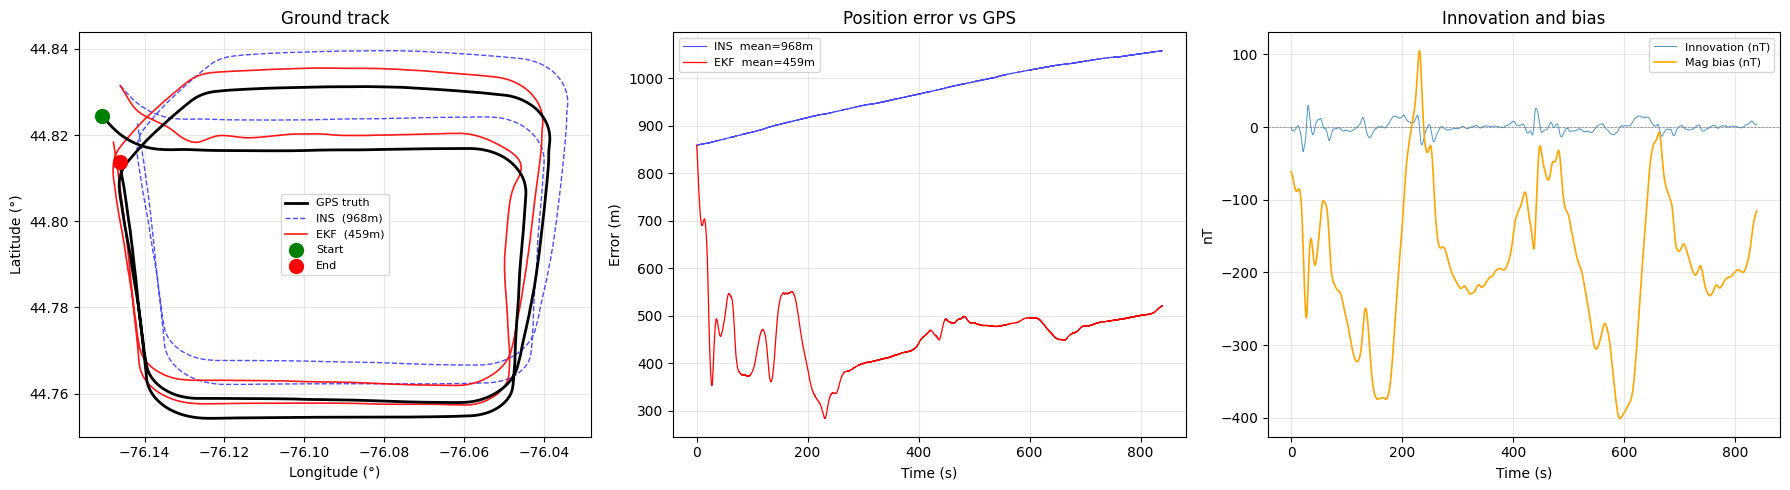

In [217]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Ground track
ax = axes[0]
ax.plot(lon_gt,        lat_gt,        'k-',  lw=2,   label='GPS truth', zorder=4)
ax.plot(ins_lon_deg,   ins_lat_deg,   'b--', lw=1,   label=f'INS  ({ins_err.mean():.0f}m)', alpha=0.7)
ax.plot(ekf['lon'],    ekf['lat'],    'r-',  lw=1.2, label=f'EKF  ({ekf_err.mean():.0f}m)', alpha=0.9)
ax.scatter(lon_gt[0],  lat_gt[0],  c='green', s=100, zorder=5, label='Start')
ax.scatter(lon_gt[-1], lat_gt[-1], c='red',   s=100, zorder=5, label='End')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Ground track')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
# Error over time
ax = axes[1]
t = df_test['tt'].values - df_test['tt'].values[0]
ax.plot(t, ins_err, 'b-', lw=0.8, alpha=0.7, label=f'INS  mean={ins_err.mean():.0f}m')
ax.plot(t, ekf_err, 'r-', lw=0.9,            label=f'EKF  mean={ekf_err.mean():.0f}m')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Error (m)')
ax.set_title('Position error vs GPS')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
# Innovation and bias
ax = axes[2]
ax.plot(t, ekf['innov'],    lw=0.7, label='Innovation (nT)', alpha=0.8)
ax.plot(t, ekf['mag_bias'], lw=1.2, label='Mag bias (nT)',   color='orange')
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('nT')
ax.set_title('Innovation and bias')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('ekf_result.png', dpi=150, bbox_inches='tight')
plt.show()
 